In [8]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 45 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (35.6 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123595 files and direc

In [1]:
!pip install openai

In [2]:
!pip install reportlab

In [3]:
# Install
!pip install deepeval

한글 폰트 설정

In [4]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

데이터 로드 및 전처리

In [5]:
import pandas as pd
import numpy as np
import io
import base64

# Excel 파일 로드
supply_demand_2022 = pd.read_excel('/content/원부자재수불부_엑셀_2022.xlsx')
supply_demand_2023 = pd.read_excel('/content/원부자재수불부_엑셀_2023.xlsx')
balance_accounts_2022 = pd.read_excel('/content/결산_엑셀_2022.xlsx')
balance_accounts_2023 = pd.read_excel('/content/결산_엑셀_2023.xlsx')
manufacturing_expense = pd.read_excel('/content/제조경비_대장_엑셀_2022_2023.xlsx')

#원부자재 수불부 파일의 재고 단가는 결측치로 1, 0으로만 구성되어 있다.
supply_demand_2022.drop(['재고 단가'], inplace=True, axis=1)
supply_demand_2023.drop(['재고 단가'], inplace=True, axis=1)

print('--------결측치 파악-------')
print('결산_엑셀_2022')
print(balance_accounts_2022.isnull().sum())
print('결산_엑셀_2023')
print(balance_accounts_2022.isnull().sum())


/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.10/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


--------결측치 파악-------
결산_엑셀_2022
코드             3089
제품명               0
규격                0
제품단위              0
당기생산수량            0
당기생산중량            0
제품별가중치            0
원재료비              0
노무비               0
제조경비              0
당기제품 총생산원가        0
제품 단위별 생산원가       0
제품 단위별 판매단가       0
제품 단위별 판매이익       0
제품 단위별 원가율        0
dtype: int64
결산_엑셀_2023
코드             3089
제품명               0
규격                0
제품단위              0
당기생산수량            0
당기생산중량            0
제품별가중치            0
원재료비              0
노무비               0
제조경비              0
당기제품 총생산원가        0
제품 단위별 생산원가       0
제품 단위별 판매단가       0
제품 단위별 판매이익       0
제품 단위별 원가율        0
dtype: int64


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


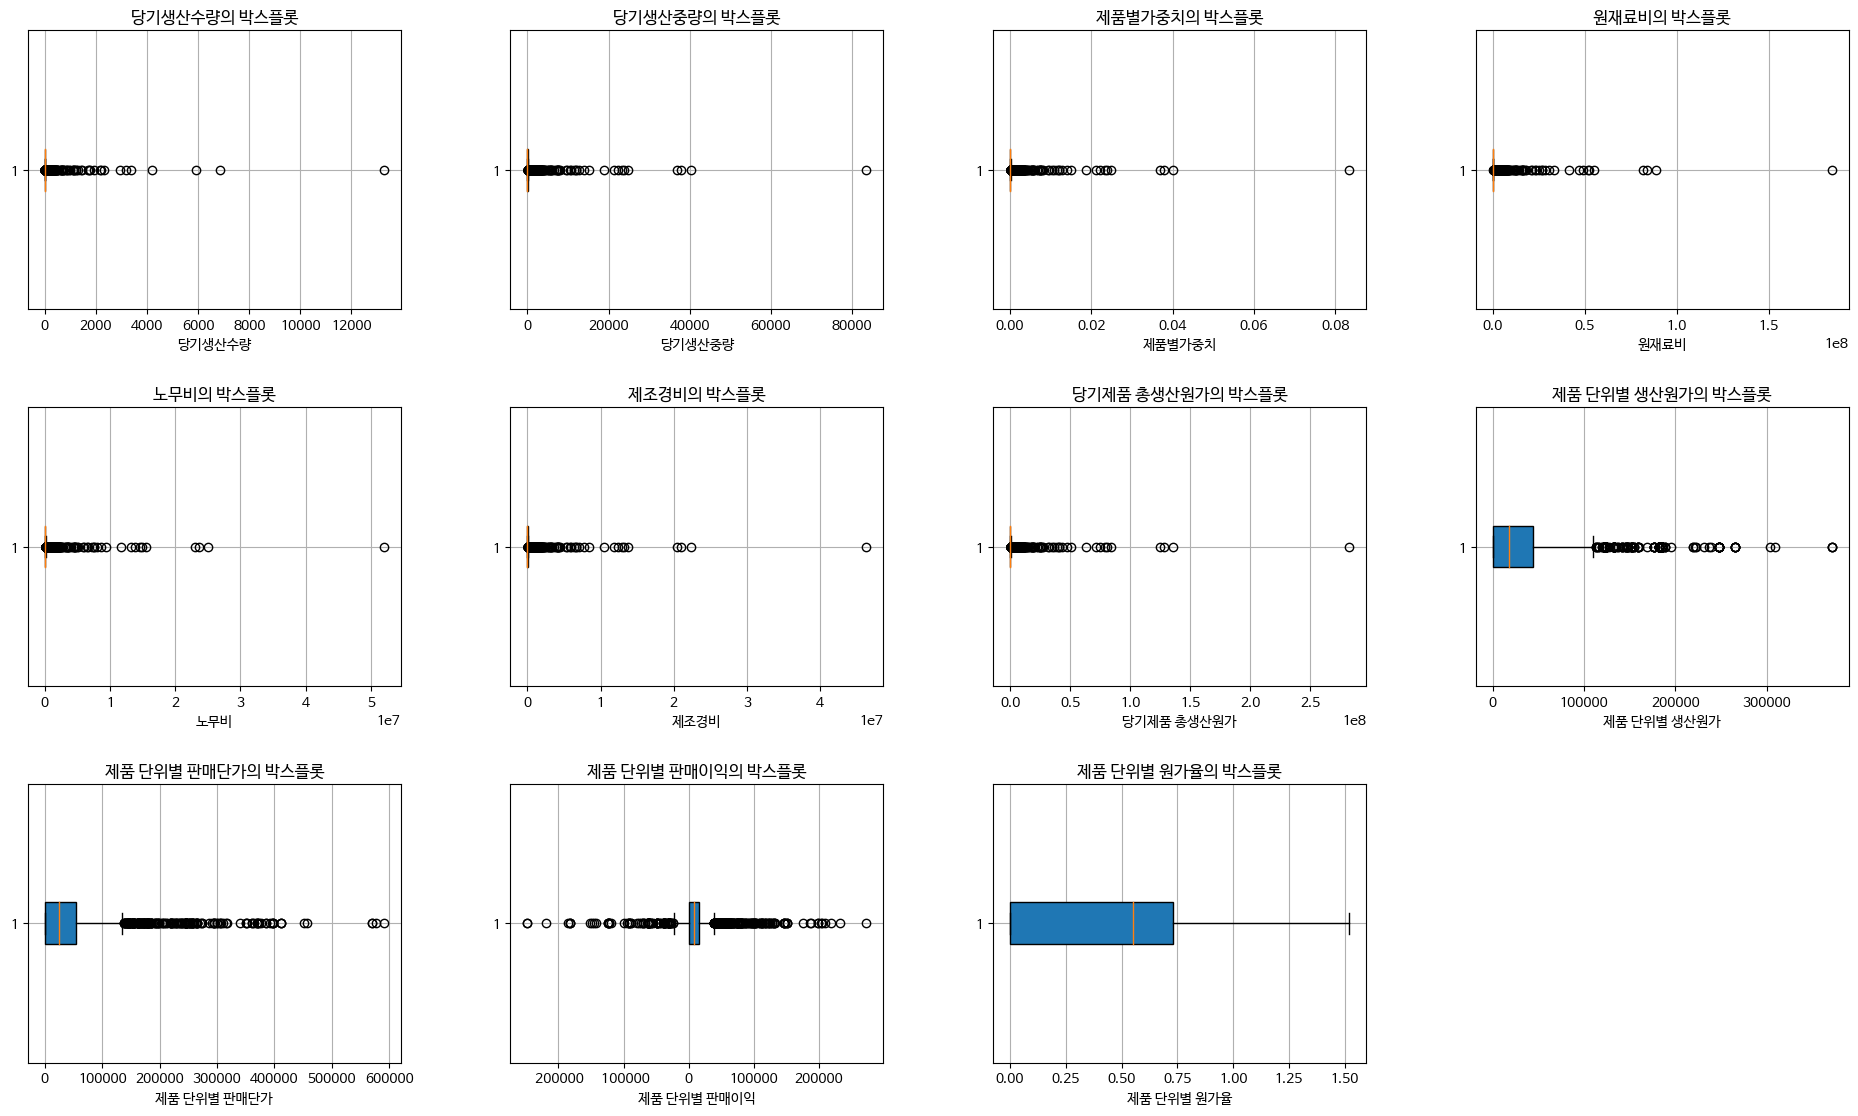

In [6]:
#결산 엑셀 파일 이상치 박스플롯
column_names = ['당기생산수량', '당기생산중량', '제품별가중치', '원재료비', '노무비', '제조경비',
       '당기제품 총생산원가', '제품 단위별 생산원가', '제품 단위별 판매단가', '제품 단위별 판매이익',
       '제품 단위별 원가율']

# 서브플롯 설정
n = len(column_names)  # 총 서브플롯 개수
ncols = 4  # 열의 개수
nrows = (n + ncols - 1) // ncols  # 필요한 행의 개수 계산

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 4 * nrows))
fig.tight_layout(pad=5.0)

# 반복문을 통해 각 컬럼에 대해 박스플롯 그리기
for i, column_name in enumerate(column_names):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]

    ax.boxplot(balance_accounts_2022[column_name].dropna(), vert=False, patch_artist=True)
    ax.set_title(f'{column_name}의 박스플롯')
    ax.set_xlabel(column_name)
    ax.grid(True)

# 빈 서브플롯 제거 (데이터가 부족할 경우)
if n % ncols != 0:
    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols, j % ncols])

plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


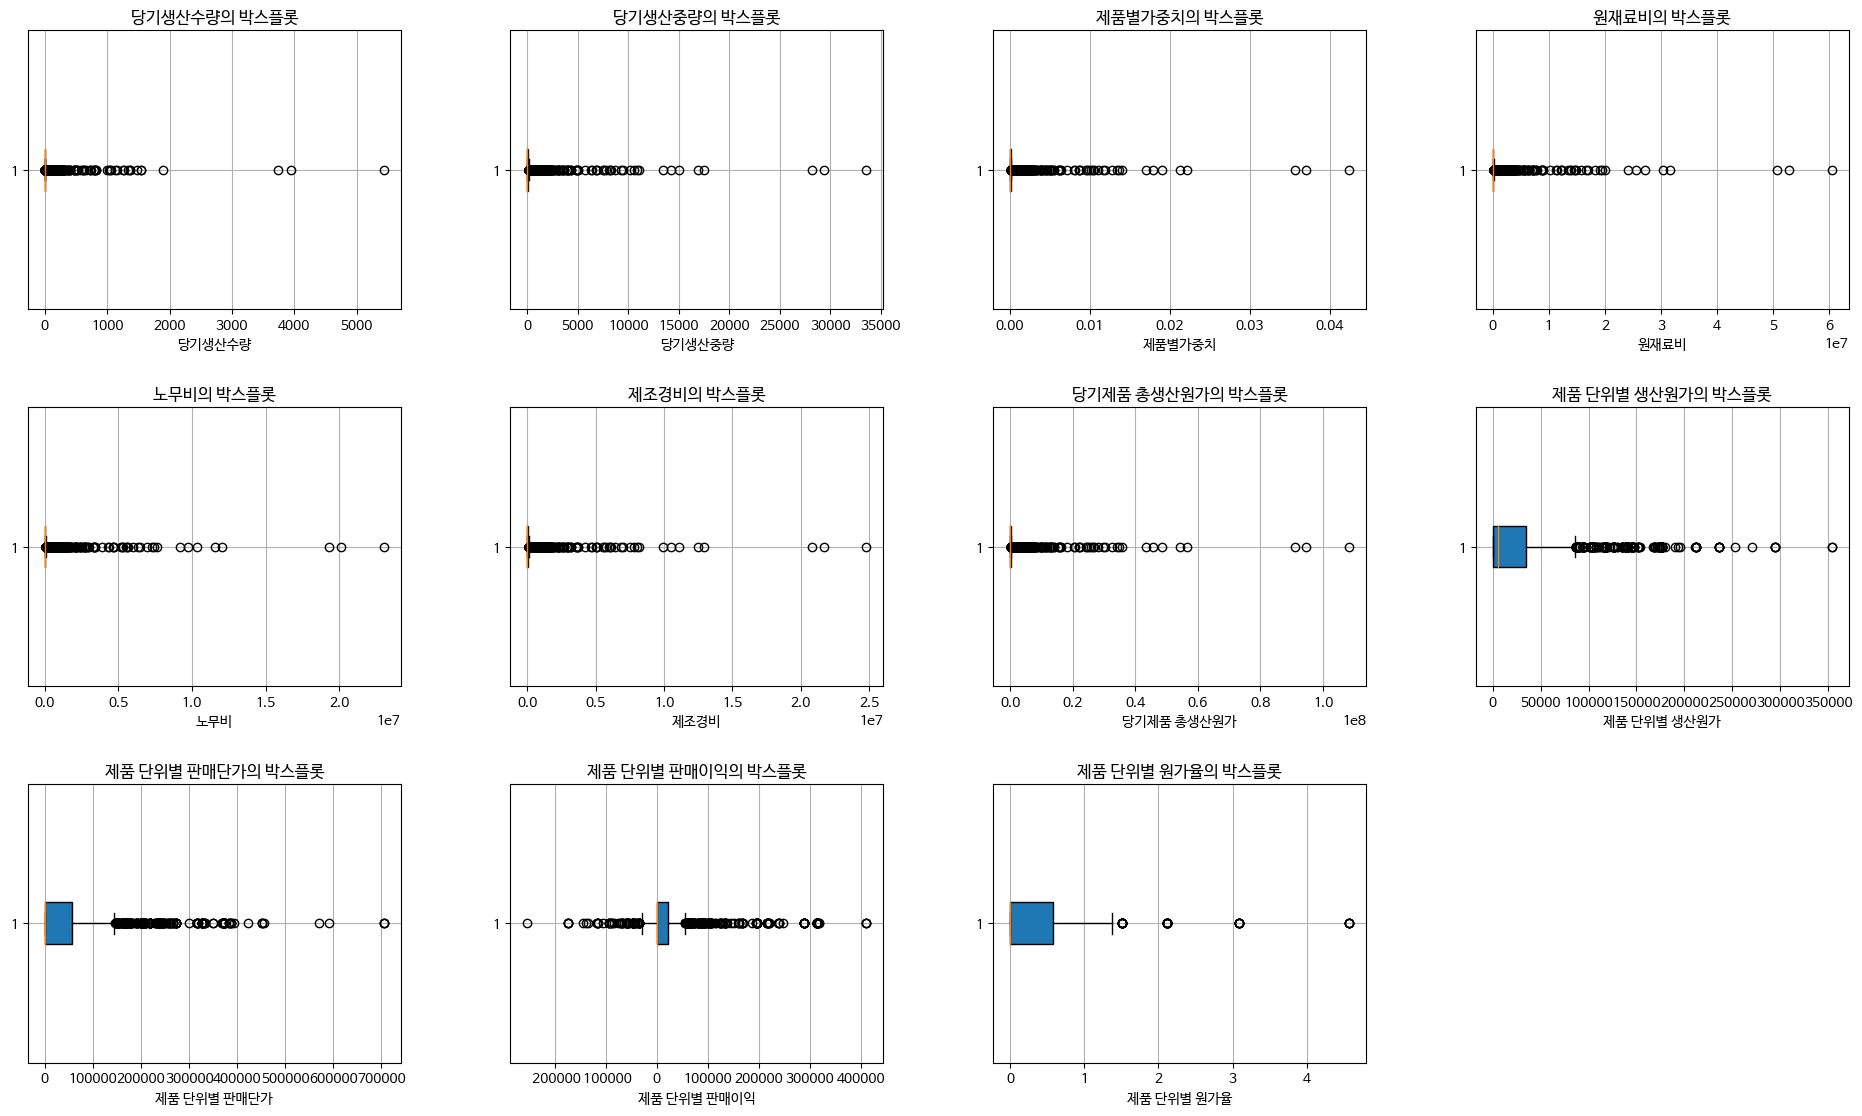

In [7]:
#결산 엑셀 파일 이상치 박스플롯
column_names = ['당기생산수량', '당기생산중량', '제품별가중치', '원재료비', '노무비', '제조경비',
       '당기제품 총생산원가', '제품 단위별 생산원가', '제품 단위별 판매단가', '제품 단위별 판매이익',
       '제품 단위별 원가율']

# 서브플롯 설정
n = len(column_names)  # 총 서브플롯 개수
ncols = 4  # 열의 개수
nrows = (n + ncols - 1) // ncols  # 필요한 행의 개수 계산

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 4 * nrows))
fig.tight_layout(pad=5.0)

# 반복문을 통해 각 컬럼에 대해 박스플롯 그리기
for i, column_name in enumerate(column_names):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]

    ax.boxplot(balance_accounts_2023[column_name].dropna(), vert=False, patch_artist=True)
    ax.set_title(f'{column_name}의 박스플롯')
    ax.set_xlabel(column_name)
    ax.grid(True)

# 빈 서브플롯 제거 (데이터가 부족할 경우)
if n % ncols != 0:
    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols, j % ncols])

plt.show()

결산_엑셀 파일 분석 및 시각화

<ipython-input-8-9c3577b164d5>:21: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig('2022년 대비 2023년 제품별 원가율 변동.png')
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


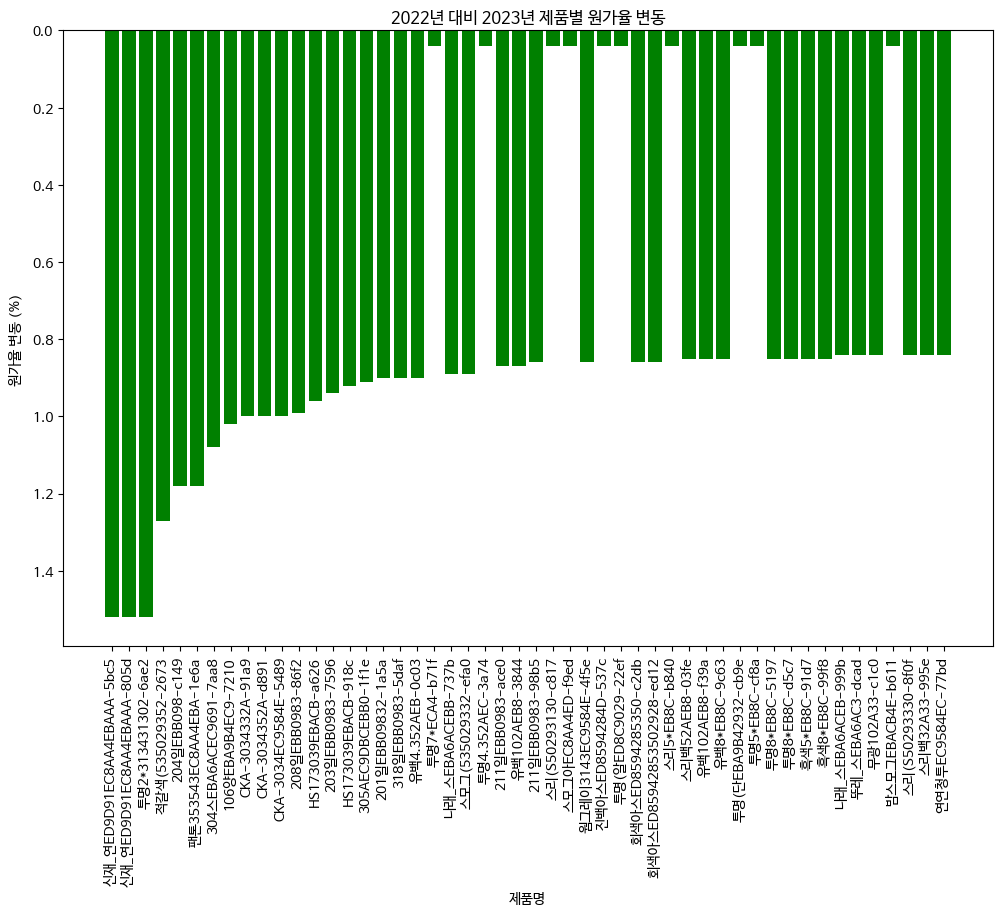

In [8]:
# 원가율이 높은 상위 50개 제품 추출
top_50_df1 = balance_accounts_2022.nlargest(50, '제품 단위별 원가율')

# 2023년 데이터와 제품명을 기준으로 매칭
balanced_accountrs_merged_df = pd.merge(top_50_df1[['제품명', '제품 단위별 원가율']], balance_accounts_2023[['제품명', '제품 단위별 원가율']], on='제품명', suffixes=('_2022', '_2023'))

# 원가율 변화 계산 늘어나면 양수
balanced_accountrs_merged_df['원가율 변동'] = balanced_accountrs_merged_df['제품 단위별 원가율_2023'] - balanced_accountrs_merged_df['제품 단위별 원가율_2022']

# 시각화
def balance_accounts_graph(merged_df):
  plt.figure(figsize=(12, 8))                      #초록색 감소한 것
  plt.bar(balanced_accountrs_merged_df['제품명'], balanced_accountrs_merged_df['원가율 변동'], color=['green' if x < 0 else 'red' for x in balanced_accountrs_merged_df['원가율 변동']])
  plt.axhline(0, color='black', linewidth=0.5)
  plt.xlabel('제품명')
  plt.ylabel('원가율 변동 (%)')
  plt.title('2022년 대비 2023년 제품별 원가율 변동')
  plt.xticks(rotation=90)
  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('2022년 대비 2023년 제품별 원가율 변동.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream
balance_accounts_graph(balanced_accountrs_merged_df)

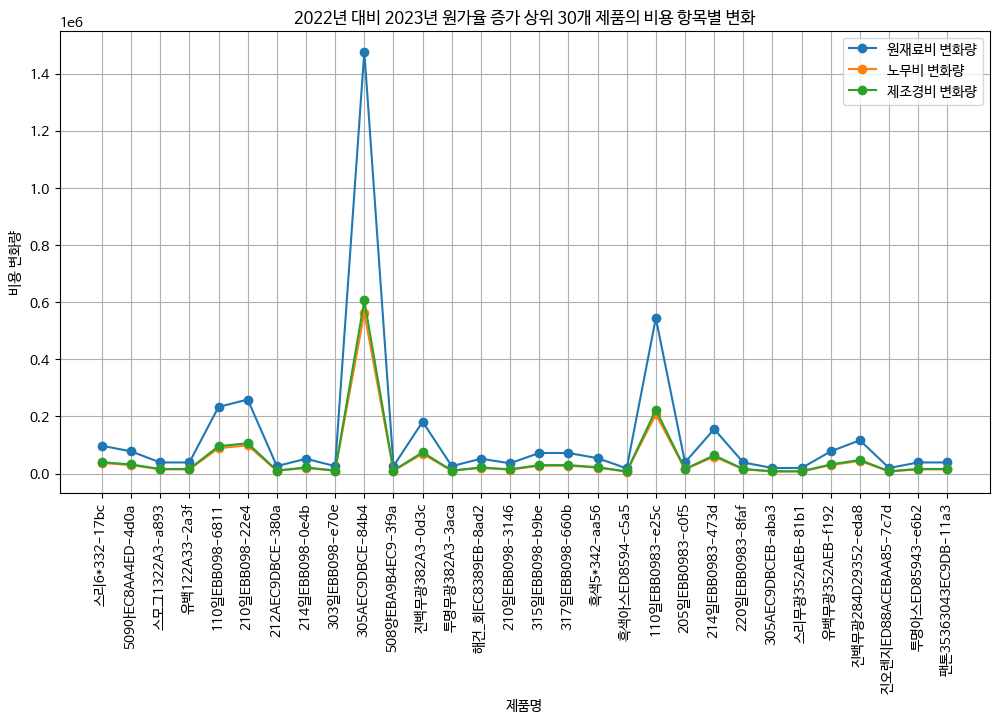

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 병합 (제품명을 기준으로)
merged_df = pd.merge(balance_accounts_2022, balance_accounts_2023, on='제품명', suffixes=('_2022', '_2023'))

# 원가율이 증가한 제품들만 필터링
merged_df['원가율 증가량'] = merged_df['제품 단위별 원가율_2023'] - merged_df['제품 단위별 원가율_2022']
increased_cost_df = merged_df[merged_df['원가율 증가량'] > 0]

# 원가율 증가량 상위 30개 제품 선택
balance_accounts_top_30 = increased_cost_df.nlargest(30, '원가율 증가량')

# 비용 항목별 변화량 계산
balance_accounts_top_30['원재료비 변화량'] = balance_accounts_top_30['원재료비_2023'] - balance_accounts_top_30['원재료비_2022']
balance_accounts_top_30['노무비 변화량'] = balance_accounts_top_30['노무비_2023'] - balance_accounts_top_30['노무비_2022']
balance_accounts_top_30['제조경비 변화량'] = balance_accounts_top_30['제조경비_2023'] - balance_accounts_top_30['제조경비_2022']

# 시각화
def balance_accounts_top30_graph(balance_accounts_top_30):
  plt.figure(figsize=(12, 6))
  plt.plot(balance_accounts_top_30['제품명'], balance_accounts_top_30['원재료비 변화량'], marker='o', label='원재료비 변화량')
  plt.plot(balance_accounts_top_30['제품명'], balance_accounts_top_30['노무비 변화량'], marker='o', label='노무비 변화량')
  plt.plot(balance_accounts_top_30['제품명'], balance_accounts_top_30['제조경비 변화량'], marker='o', label='제조경비 변화량')

  # 그래프 꾸미기
  plt.xlabel('제품명')
  plt.ylabel('비용 변화량')
  plt.title('2022년 대비 2023년 원가율 증가 상위 30개 제품의 비용 항목별 변화')
  plt.xticks(rotation=90)
  plt.legend()
  plt.grid(True)
  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('2022년 대비 2023년 원가율 증가 상위 30개 제품의 비용 항목별 변화.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream
balance_accounts_top30_graph(balance_accounts_top_30)

<ipython-input-10-30732a36a043>:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(df_top_2022['제품명'], rotation=90)
<ipython-input-10-30732a36a043>:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(df_top_2023['제품명'], rotation=90)


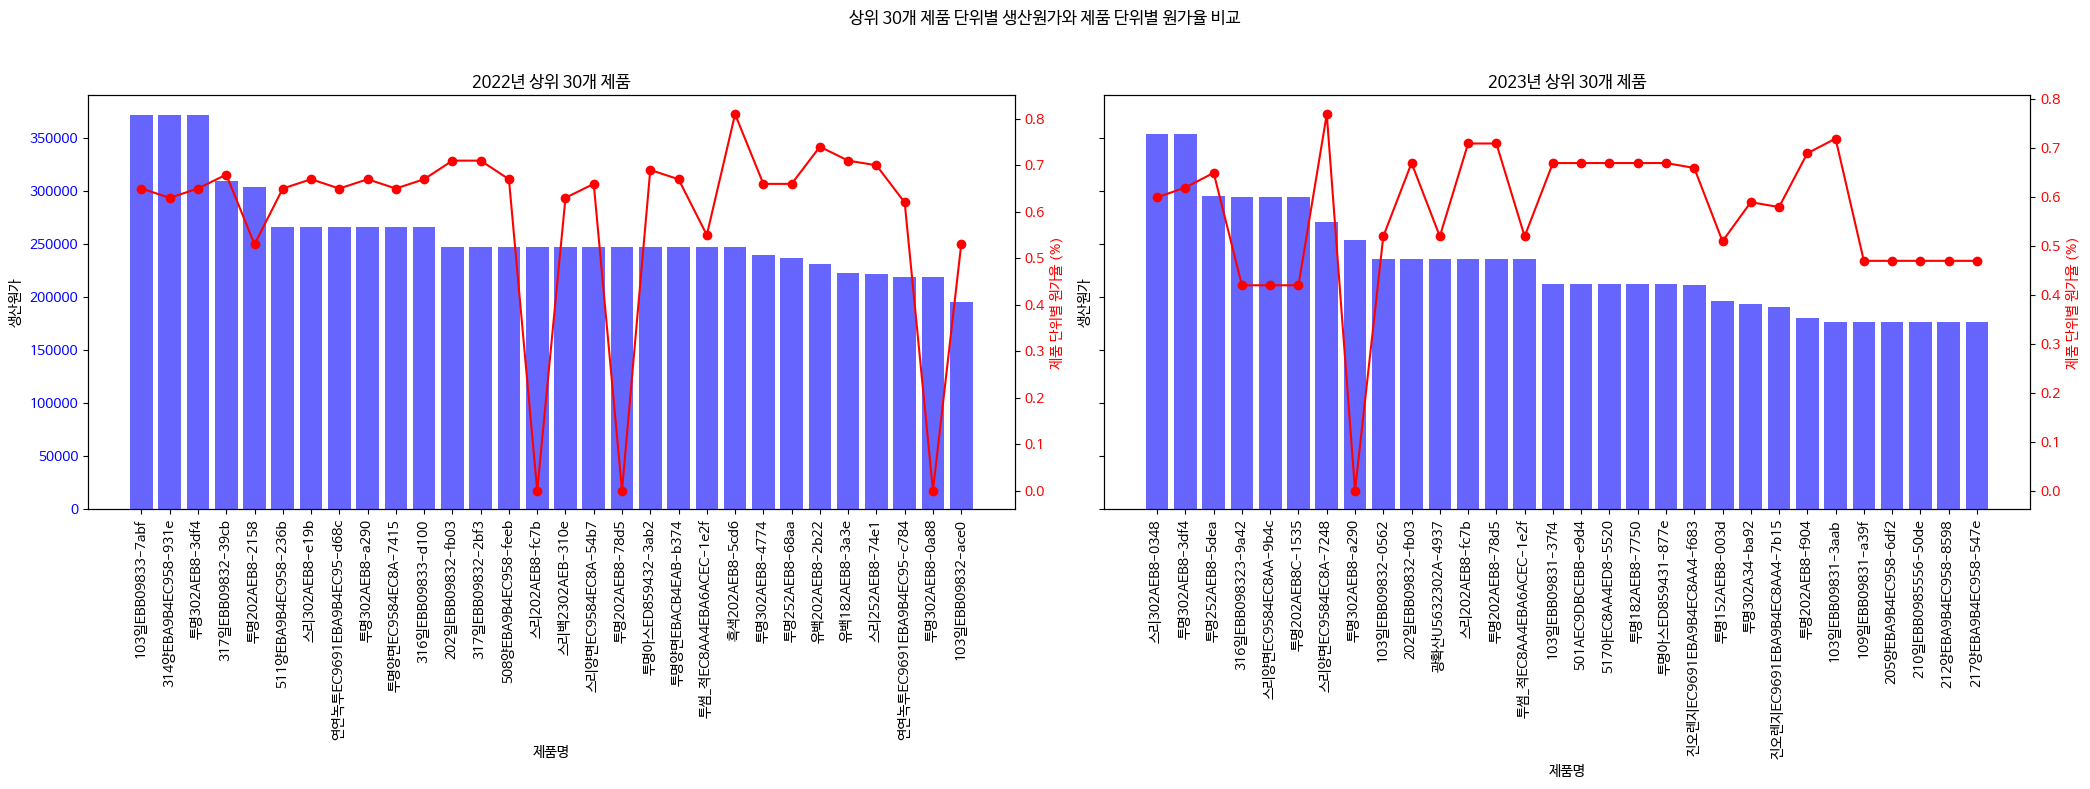

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import io

def balance_accounts_top30_cost_graph(balance_accounts_2022, balance_accounts_2023, top_n=30):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 8), sharey=True)

    # 2022년 데이터 처리
    df_2022 = balance_accounts_2022[['제품명', '제품 단위별 생산원가', '제품 단위별 원가율']]
    df_top_2022 = df_2022.nlargest(top_n, '제품 단위별 생산원가')

    # 2023년 데이터 처리
    df_2023 = balance_accounts_2023[['제품명', '제품 단위별 생산원가', '제품 단위별 원가율']]
    df_top_2023 = df_2023.nlargest(top_n, '제품 단위별 생산원가')

    # 2022년 그래프
    ax1.bar(df_top_2022['제품명'], df_top_2022['제품 단위별 생산원가'], color='b', alpha=0.6, label='제품 단위별 생산원가')
    ax1.set_xlabel('제품명')
    ax1.set_ylabel('생산원가')
    ax1.set_title('2022년 상위 30개 제품')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticklabels(df_top_2022['제품명'], rotation=90)

    ax1_line = ax1.twinx()
    ax1_line.plot(df_top_2022['제품명'], df_top_2022['제품 단위별 원가율'], color='r', marker='o', label='제품 단위별 원가율')
    ax1_line.set_ylabel('제품 단위별 원가율 (%)', color='r')
    ax1_line.tick_params(axis='y', labelcolor='r')

    # 2023년 그래프
    ax2.bar(df_top_2023['제품명'], df_top_2023['제품 단위별 생산원가'], color='b', alpha=0.6, label='제품 단위별 생산원가')
    ax2.set_xlabel('제품명')
    ax2.set_ylabel('생산원가')
    ax2.set_title('2023년 상위 30개 제품')
    ax2.tick_params(axis='y', labelcolor='b')
    ax2.set_xticklabels(df_top_2023['제품명'], rotation=90)

    ax2_line = ax2.twinx()
    ax2_line.plot(df_top_2023['제품명'], df_top_2023['제품 단위별 원가율'], color='r', marker='o', label='제품 단위별 원가율')
    ax2_line.set_ylabel('제품 단위별 원가율 (%)', color='r')
    ax2_line.tick_params(axis='y', labelcolor='r')

    # 그래프 제목 및 범례 설정
    fig.suptitle(f'상위 {top_n}개 제품 단위별 생산원가와 제품 단위별 원가율 비교')
    fig.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to fit the suptitle

    image_stream = io.BytesIO()
    #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
    plt.savefig('상위 30개 제품 단위별 생산원가와 제품 단위별 원가율 비교.png')
    plt.show()
    plt.close()
    image_stream.seek(0)
    return image_stream

balance_accounts_top30_cost_graph(balance_accounts_2022, balance_accounts_2023)

원부자재수불부 엑셀 파일 데이터 분석 및 시각화
- 원부자재수불부 데이터를 분석하여 전기와 당기에 많이 사용된 순으로 원재료 정렬 (금액 기준)

In [11]:
# 2022년도 데이터 처리
supply_demand_2022_sorted = supply_demand_2022.sort_values(by='총 출고금액', ascending=False).head(10)

# 2023년도 데이터 처리
supply_demand_2023_sorted = supply_demand_2023.sort_values(by='총 출고금액', ascending=False).head(10)

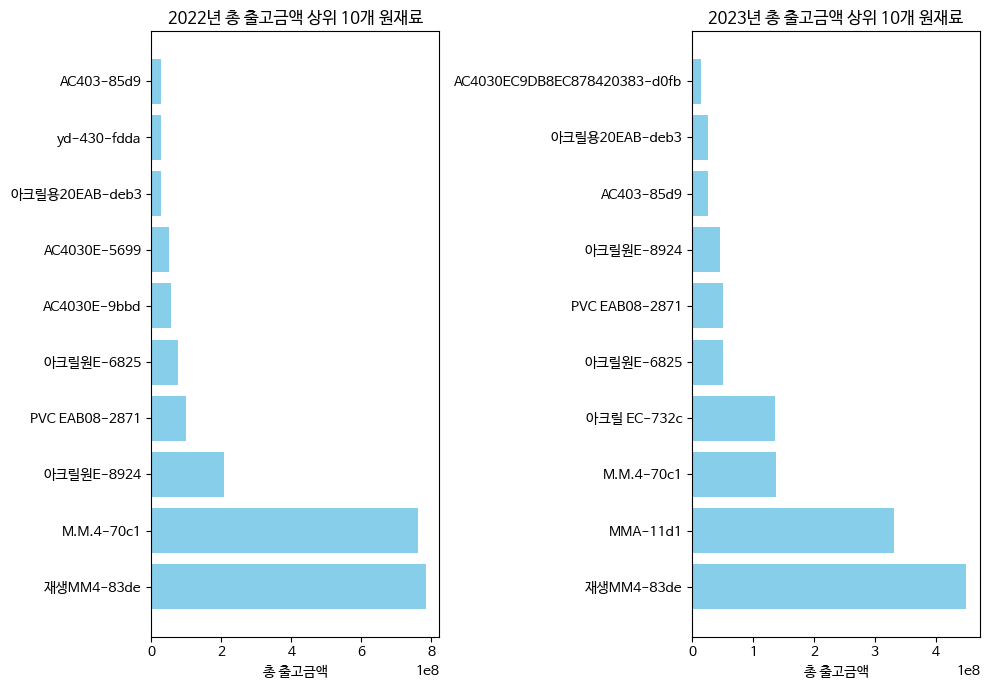

In [12]:
def supply_demand_graph(supply_demand_2022_sorted, supply_demand_2023_sorted):
  plt.figure(figsize=(10, 7))

  plt.subplot(1, 2, 1)
  plt.barh(supply_demand_2022_sorted['원재료명'], supply_demand_2022_sorted['총 출고금액'], color='skyblue')
  plt.xlabel('총 출고금액')
  plt.title('2022년 총 출고금액 상위 10개 원재료')
  plt.subplot(1, 2, 2)
  plt.barh(supply_demand_2023_sorted['원재료명'], supply_demand_2023_sorted['총 출고금액'], color='skyblue')
  plt.xlabel('총 출고금액')
  plt.title('2023년 총 출고금액 상위 10개 원재료')
  plt.tight_layout()

  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('총 출고금액 상위 10개 원재료.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream

# 2022년 vs. 2023년도 총 출고금액 상위 10개 원자료
supply_demand_graph(supply_demand_2022_sorted, supply_demand_2023_sorted)

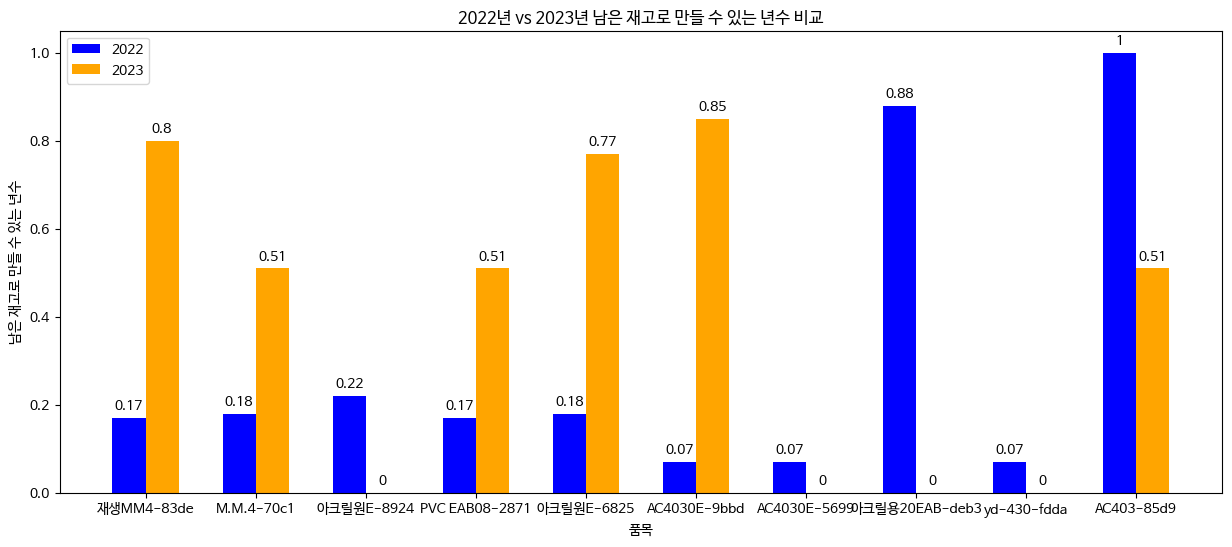

In [13]:
#앞으로 생산가능한 양 계산
#supply_demand_2022_sorted['기말 재고량'] / supply_demand_2022_sorted['총 출고량']

def supply_demand_remain(supply_demand_2022_sorted, supply_demand_2023_sorted):
  # '기말 재고량 / 총 출고량' 계산
  supply_demand_2022_sorted['남은 재고로 만들 수 있는 년수'] = supply_demand_2022_sorted['기말 재고량'] / supply_demand_2022_sorted['총 출고량']
  supply_demand_2023_sorted['남은 재고로 만들 수 있는 년수'] = supply_demand_2023_sorted['기말 재고량'] / supply_demand_2023_sorted['총 출고량']

  # 시각화
  labels = supply_demand_2022_sorted['원재료명']
  years_2022 = np.round(supply_demand_2022_sorted['남은 재고로 만들 수 있는 년수'],2)
  years_2023 = np.round(supply_demand_2023_sorted['남은 재고로 만들 수 있는 년수'], 2)

  x = np.arange(len(labels))  # 품목 위치
  width = 0.3  # 막대 너비

  fig, ax = plt.subplots(figsize=(15, 6))
  bars1 = ax.bar(x - width/2, years_2022, width, label='2022', color='blue')
  bars2 = ax.bar(x + width/2, years_2023, width, label='2023', color='orange')

  # 제목 및 라벨 설정
  ax.set_xlabel('품목')
  ax.set_ylabel('남은 재고로 만들 수 있는 년수')
  ax.set_title('2022년 vs 2023년 남은 재고로 만들 수 있는 년수 비교')
  ax.set_xticks(x)
  ax.set_xticklabels(labels)
  ax.legend()

  # 그래프를 보기 쉽게 하기 위한 레이블 표시
  ax.bar_label(bars1, padding=3)
  ax.bar_label(bars2, padding=3)

  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('2022년 대비 2023년 남은 재고로 만들 수 있는 년수 비교.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream

#2022년 vs. 2023년 남은 재고로 만들 수 있는 년수 비교
supply_demand_remain(supply_demand_2022_sorted, supply_demand_2023_sorted)

제조경비 대장 2022 vs. 2023 데이터 분석 및 시각화

항목
'''
1. 노무비
    1. 급여
    2. 상여금
    3. 퇴직급여(퇴직연금)
    4. 퇴직급여
    5. 잡급
2. 경비
    1. 노무비를 제외한 항목들
    '''

In [14]:
expenses_dict = {
    "급여": ["노무비"],
    "상여금": ["노무비"],
    "퇴직급여(퇴직연금)": ["노무비"],
    "퇴직급여": ["노무비"],
    "복리후생비": ["경비"],
    "여비교통비": ["경비"],
    "통신비": ["경비"],
    "가스수도료": ["경비"],
    "전력비": ["경비"],
    "감가상각비": ["경비"],
    "수선비": ["경비"],
    "보험료": ["경비"],
    "차량유지비": ["경비"],
    "운반비": ["경비"],
    "도서인쇄비": ["경비"],
    "소모품비": ["경비"],
    "지급수수료": ["경비"],
    "잡급": ["노무비"],
    "교육훈련비": ["경비"]
}

manufacturing_expense['비용구분'] = manufacturing_expense['계정명'].map(lambda x: expenses_dict.get(x, ['기타'])[0])

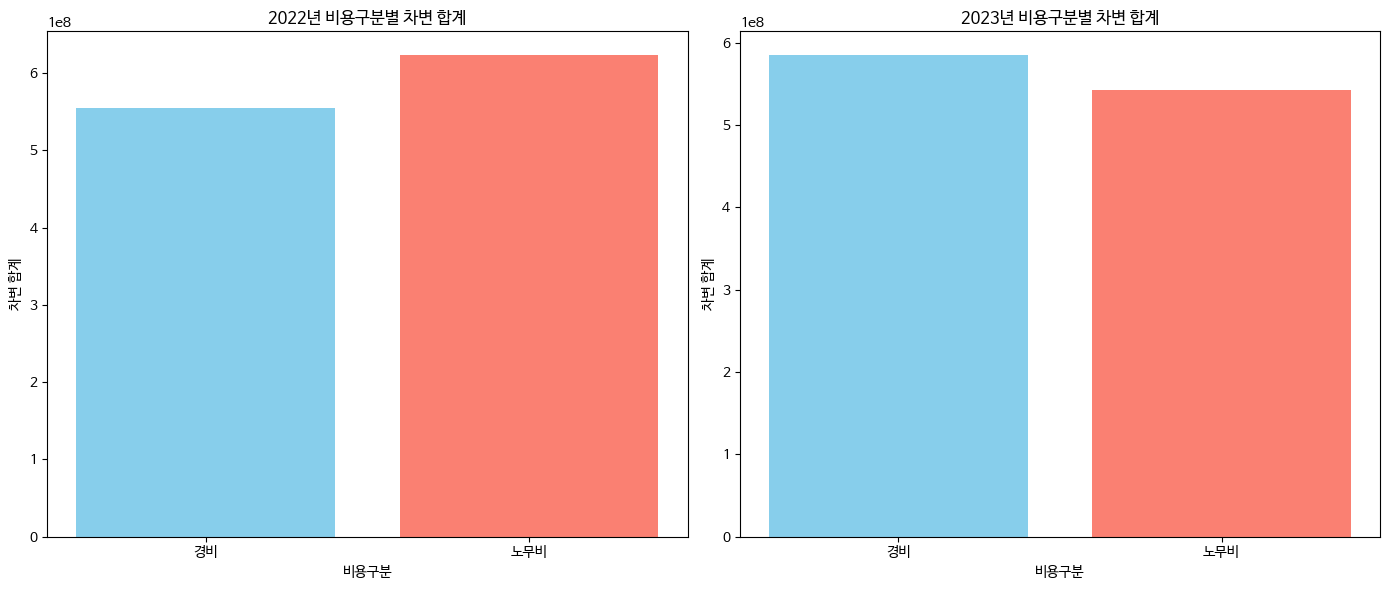

In [15]:
# '등록일'을 연도와 월로 분리
manufacturing_expense['연도'] = manufacturing_expense['등록일'].dt.year

# 2022년과 2023년 데이터 필터링
df_2022 = manufacturing_expense[manufacturing_expense['연도'] == 2022]
df_2023 = manufacturing_expense[manufacturing_expense['연도'] == 2023]

# 연도 및 비용구분으로 그룹화하고 '차변'의 합계 계산
df_2022_summary = df_2022.groupby('비용구분')['차변'].sum().reset_index()
df_2023_summary = df_2023.groupby('비용구분')['차변'].sum().reset_index()

def expenses_graph(df_2022_summary, df_2023_summary):
  # 그래프 시각화
  fig, ax = plt.subplots(1, 2, figsize=(14, 6))

  # 2022년 그래프
  ax[0].bar(df_2022_summary['비용구분'], df_2022_summary['차변'], color=['skyblue', 'salmon'])
  ax[0].set_title('2022년 비용구분별 차변 합계')
  ax[0].set_xlabel('비용구분')
  ax[0].set_ylabel('차변 합계')

  # 2023년 그래프
  ax[1].bar(df_2023_summary['비용구분'], df_2023_summary['차변'], color=['skyblue', 'salmon'])
  ax[1].set_title('2023년 비용구분별 차변 합계')
  ax[1].set_xlabel('비용구분')
  ax[1].set_ylabel('차변 합계')

  plt.tight_layout()

  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('2022년 대비 2023년 비용구분별 차변 합계.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream

#2022년 vs. 2023년 비용구분별 차변 합계
expenses_graph(df_2022_summary, df_2023_summary)

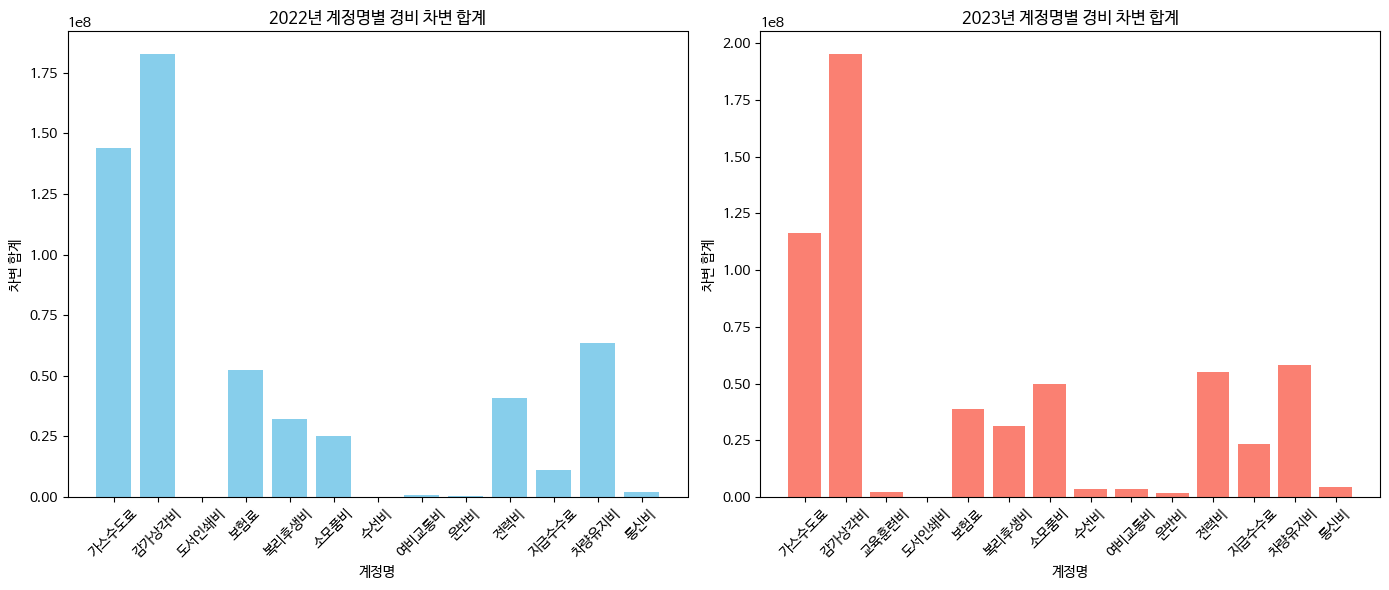

In [16]:
#2023년에 경비를 더 많이 씀 => 구체적으로 어떤 항목?
# 2022년과 2023년 데이터 필터링
df_2022 = manufacturing_expense[manufacturing_expense['등록일'].dt.year == 2022]
df_2023 = manufacturing_expense[manufacturing_expense['등록일'].dt.year == 2023]

# '경비' 항목만 필터링
df_2022_expenses = df_2022[df_2022['비용구분'] == '경비']
df_2023_expenses = df_2023[df_2023['비용구분'] == '경비']

# 계정명별로 차변 합계 계산
df_2022_expenses_summary = df_2022_expenses.groupby('계정명')['차변'].sum().reset_index()
df_2023_expenses_summary = df_2023_expenses.groupby('계정명')['차변'].sum().reset_index()

def expenses_item_graph(df_2022_expenses_summary, df_2023_expenses_summary):
  # 그래프 시각화
  fig, ax = plt.subplots(1, 2, figsize=(14, 6))

  # 2022년 경비 그래프
  ax[0].bar(df_2022_expenses_summary['계정명'], df_2022_expenses_summary['차변'], color='skyblue')
  ax[0].set_title('2022년 계정명별 경비 차변 합계')
  ax[0].set_xlabel('계정명')
  ax[0].set_ylabel('차변 합계')
  ax[0].tick_params(axis='x', rotation=45)

  # 2023년 경비 그래프
  ax[1].bar(df_2023_expenses_summary['계정명'], df_2023_expenses_summary['차변'], color='salmon')
  ax[1].set_title('2023년 계정명별 경비 차변 합계')
  ax[1].set_xlabel('계정명')
  ax[1].set_ylabel('차변 합계')
  ax[1].tick_params(axis='x', rotation=45)

  plt.tight_layout()

  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('2022년 대비 2023년 계정명별 경비 차변 합계.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream

#2022년 vs. 2023년 계정명별 경비 차변 합계
expenses_item_graph(df_2022_expenses_summary, df_2023_expenses_summary)

#소모품비와 전력가 많이 증가

제조경비 항목을 월별로 집계한 결과:
                차변  대변
월                     
2022-01   87019583   0
2022-02   75175373   0
2022-03   81169613   0
2022-04   74324487   0
2022-05   78494681   0
2022-06   79746313   0
2022-07   86840686   0
2022-08   72961956   0
2022-09   96657690   0
2022-10   85293892   0
2022-11   88181068   0
2022-12  272635141   0
2023-01   91487167   0
2023-02   69372717   0
2023-03   81136847   0
2023-04   92545449   0
2023-05   59487087   0
2023-06   66484907   0
2023-07   70002656   0
2023-08   58763585   0
2023-09  103363860   0
2023-10   72778114   0
2023-11   71689419   0
2023-12  289904484   0

차변이 큰 순서대로 상위 3개:
월
2023-12    289904484
2022-12    272635141
2023-09    103363860
Freq: M, Name: 차변, dtype: int64


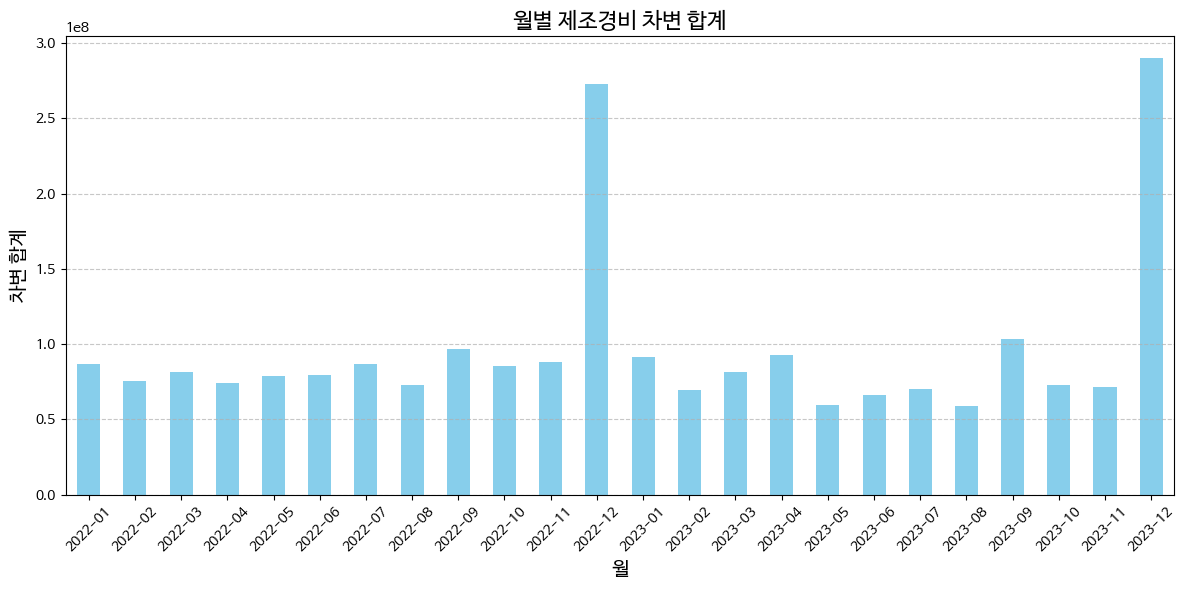

In [17]:
#import os
# 필요한 컬럼만 추출
manufacturing_expense = manufacturing_expense[['계정명', '차변', '대변', '등록일']]

# 날짜 형식으로 변환
manufacturing_expense.loc[:, '등록일'] = pd.to_datetime(manufacturing_expense['등록일'])

# 제조경비와 노무비 항목 필터링
relevant_categories = [
    '급여', '상여금', '퇴직급여(퇴직연금)', '퇴직급여', '복리후생비', '여비교통비',
    '통신비', '가스수도료', '전력비', '감가상각비', '수선비', '보험료',
    '차량유지비', '운반비', '도서인쇄비', '소모품비', '지급수수료', '잡급', '교육훈련비'
]
df_filtered = manufacturing_expense[manufacturing_expense['계정명'].isin(relevant_categories)]

# 월별 비용 집계
df_filtered['월'] = df_filtered['등록일'].dt.to_period('M')
monthly_expense = df_filtered.groupby(['월']).agg({'차변': 'sum', '대변': 'sum'})

"""
# 결과를 CSV 파일로 저장
monthly_expense_csv = '/monthly_expense.csv'
os.makedirs(os.path.dirname(monthly_expense_csv), exist_ok=True)
monthly_expense.to_csv(monthly_expense_csv, index=True)
"""

# 월별 비용 집계 결과를 출력
print("제조경비 항목을 월별로 집계한 결과:")
print(monthly_expense)

# 차변이 큰 순서대로 상위 3개 월 출력
top_3_expenses = monthly_expense['차변'].nlargest(3)
print("\n차변이 큰 순서대로 상위 3개:")
print(top_3_expenses)

def monthly_expense_graph(monthly_expense):
  # 막대 그래프로 시각화
  plt.figure(figsize=(12, 6))
  monthly_expense['차변'].plot(kind='bar', color='skyblue')

  # 그래프 제목과 레이블 설정
  plt.title('월별 제조경비 차변 합계', fontsize=16)
  plt.xlabel('월', fontsize=14)
  plt.ylabel('차변 합계', fontsize=14)
  plt.xticks(rotation=45)
  plt.grid(axis='y', linestyle='--', alpha=0.7)

  # 그래프 레이아웃 조정 및 저장
  plt.tight_layout()
  """
  graph_path = '/monthly_expense_graph.png'
  os.makedirs(os.path.dirname(graph_path), exist_ok=True)
  plt.savefig(graph_path)
  """
  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('월별 제조경비 차변 합계.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream

#월별 제조경비 차변 합계
monthly_expense_graph(monthly_expense)

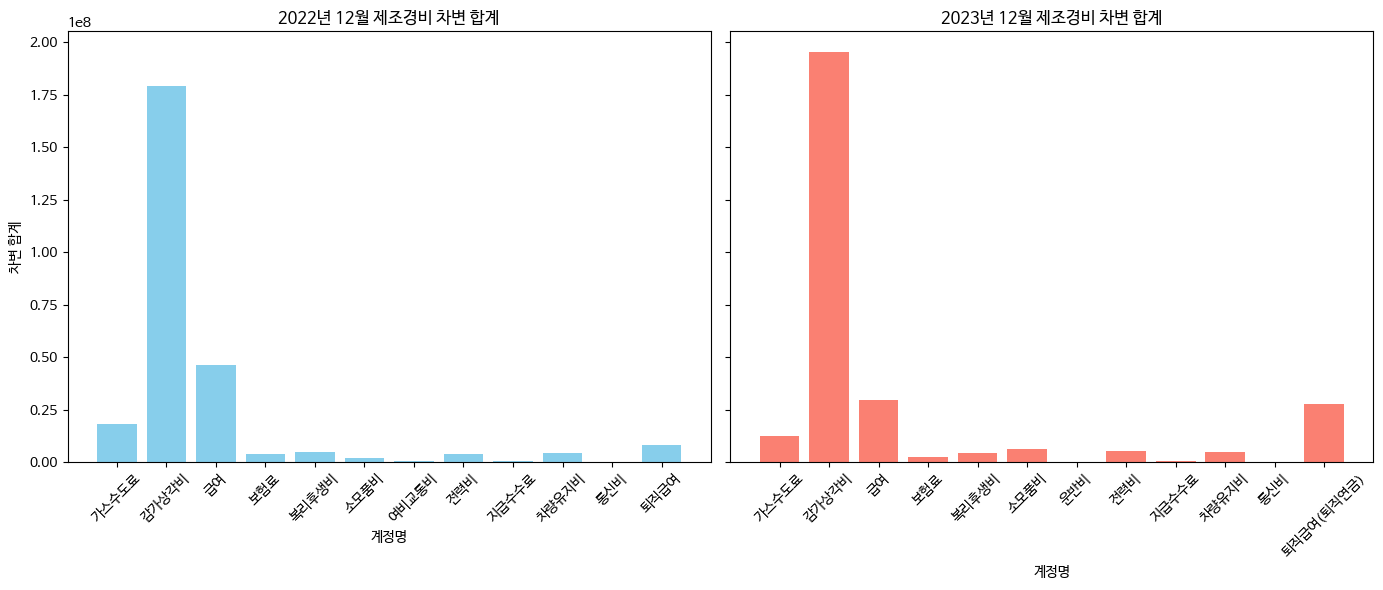

In [18]:
# 날짜 형식 변환
manufacturing_expense['등록일'] = pd.to_datetime(manufacturing_expense['등록일'])

# 2022년 12월과 2023년 12월 데이터 필터링
df_dec_2022 = manufacturing_expense[(manufacturing_expense['등록일'].dt.year == 2022) & (manufacturing_expense['등록일'].dt.month == 12)]
df_dec_2023 = manufacturing_expense[(manufacturing_expense['등록일'].dt.year == 2023) & (manufacturing_expense['등록일'].dt.month == 12)]

# 계정명 별로 차변 합계 계산
expense_2022 = df_dec_2022.groupby('계정명')['차변'].sum()
expense_2023 = df_dec_2023.groupby('계정명')['차변'].sum()

# 시각화
def manufacturing_plot(expense_2022, expense_2023):
  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

  # 2022년 12월 차변 시각화
  axes[0].bar(expense_2022.index, expense_2022.values, color='skyblue')
  axes[0].set_title('2022년 12월 제조경비 차변 합계')
  axes[0].set_xlabel('계정명')
  axes[0].set_ylabel('차변 합계')
  axes[0].tick_params(axis='x', rotation=45)

  # 2023년 12월 차변 시각화
  axes[1].bar(expense_2023.index, expense_2023.values, color='salmon')
  axes[1].set_title('2023년 12월 제조경비 차변 합계')
  axes[1].set_xlabel('계정명')
  axes[1].tick_params(axis='x', rotation=45)

  # 그래프 레이아웃 조정 및 출력
  plt.tight_layout()

  image_stream = io.BytesIO()
  #plt.savefig(image_stream, format='png', bbox_inches='tight') #버퍼에 저장됨
  plt.savefig('12월 제조경비 차변 합계 비교.png')
  plt.show()
  plt.close()
  image_stream.seek(0)
  return image_stream

manufacturing_plot(expense_2022, expense_2023)

PDF 파일 생성

In [ ]:
##################################################################################################
api_key = 

In [20]:
#reference: https://community.openai.com/t/using-an-image-as-input-gpt4-api/793152/2
import requests
def encode_image(image_path):
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {api_key}"
  }
def gpt_response(image_path, question):
  image64 = encode_image(image_path)

  payload = {
    "model": "gpt-4o",
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": question
          },
          {
            "type": "image_url",
            "image_url": {
              "url": f"data:image/jpeg;base64,{image64}"
            }
          }
        ]
      },
      {
          "role": "system",
          "content": "You are a professional CEO designed to offer business management report. 두괄식으로 읽기 쉽게 300자 이내로 작성해"
      },
      {
          "role": "assistant",
          "content": '''⚫ 성과평가지표 名이 측정/관리를 위한 대상 업무를 명확하게 반영하지못함
                        ⚫ 일부 성과평가지표의 경우, 상세한 성과를 측정하기 위한 지표의 세분화가 필요함
                        ⚫ 일부 성과평가지표의 경우, 성과평가지표 名과 상이한 산식을, 혹은 잘못된 로직으로 산식이 정의되어 성과평가결과가 왜곡될 수 있음}
        '''
      }
    ],
    "max_tokens": 1000
  }

  response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)
  return response.json()


In [21]:
def gpt_text(question):
  payload = {
    "model": "gpt-4o",
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": question
          },
        ]
      },
      {
          "role": "system",
          "content": "You are a professional CEO designed to offer business management report. 두괄식으로 읽기 쉽게 300자 이내로 작성해."
      },
      {
          "role": "assistant",
          "content":
          '''<원가분석결과 원재료의 과잉 투입현상 발견>
                      -> 표준 BOM상 원재료 투입 비용 : 1,316,953원
                      -> 실제 원재료 투입 비용 : 1,325,123원
                      원인 : MMA배합 및 규격틀 이관 과정에서 Human Error로 인한 Loss현상 발생
                      해결방안 : 자동화 기계 도입 필수 '''
      }
    ],
    "max_tokens": 500
  }

  response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)
  return response.json()
gpt_text('''<원가분석결과 원재료의 과잉 투입현상 발견>
                      -> 표준 BOM상 원재료 투입 비용 : 1,316,953원
                      -> 실제 원재료 투입 비용 : 1,325,123원
                      원인 : MMA배합 및 규격틀 이관 과정에서 Human Error로 인한 Loss현상 발생
                      해결방안 : 자동화 기계 도입 필수 ''')

{'id': 'chatcmpl-9z3tqpCf9fJvX6vQQHlvbFEMoFDfQ',
 'object': 'chat.completion',
 'created': 1724340026,
 'model': 'gpt-4o-2024-05-13',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '원가분석 결과, 원재료 과잉 투입으로 발생한 손실이 발견되었습니다. 표준 BOM상 원재료 투입 비용은 1,316,953원이었으나, 실제 투입 비용은 1,325,123원으로 차이가 발생했습니다. 이는 MMA 배합 및 규격틀 이관 과정에서 발생한 Human Error로 인한 손실로 나타났습니다. 이러한 문제를 해결하기 위해 자동화 기계 도입이 필수적입니다. 이를 통해 원재료 투입의 정확성을 높이고, 비용 절감과 효율성 증대를 기대할 수 있습니다.',
    'refusal': None},
   'logprobs': None,
   'finish_reason': 'stop'}],
 'usage': {'prompt_tokens': 240,
  'completion_tokens': 134,
  'total_tokens': 374},
 'system_fingerprint': 'fp_3aa7262c27'}

In [22]:
#Example

question = '2022년 2023년도 비교하여 제품단위별 원자재비용과 원가율 추이를 보고 판매단가를 분석해줘'
response = gpt_response('/content/총 출고금액 상위 10개 원재료.png', question)['choices'][0]['message']['content']

In [23]:
import pprint
pprint.pprint(response)

('2022년과 2023년 총 출고금액 상위 10개 원자재를 비교했을 때, 주요 원자재의 출고금액이 꾸준히 증가하고 있습니다. '
 "'재생MMA4-83de'와 'M.M.4-70c1'는 두 해에 걸쳐 상위권을 유지하고 있으며, 특히 'MMA-11d1'는 2023년 큰 "
 '변화를 보였습니다. 원자재비용과 원가율의 증가로 인해 판매단가 조정이 불가피할 수 있습니다. 향후 고려할 사항은, 원자재비용 상승에 따른 '
 '판매단가 인상 전략과 더불어, 효율적인 재고 관리 및 대체 원자재 활용 방안 등입니다.')


In [24]:
from markdown import markdown
# 마크다운을 HTML로 변환하는 함수 (ReportLab의 paragraph가 제대로 지원하지 않으나, *, # 등이 제거됨)
def markdown_to_html(markdown_text):
    html_text = markdown(markdown_text)
    return html_text
markdown_to_html(response)

"<p>2022년과 2023년 총 출고금액 상위 10개 원자재를 비교했을 때, 주요 원자재의 출고금액이 꾸준히 증가하고 있습니다. '재생MMA4-83de'와 'M.M.4-70c1'는 두 해에 걸쳐 상위권을 유지하고 있으며, 특히 'MMA-11d1'는 2023년 큰 변화를 보였습니다. 원자재비용과 원가율의 증가로 인해 판매단가 조정이 불가피할 수 있습니다. 향후 고려할 사항은, 원자재비용 상승에 따른 판매단가 인상 전략과 더불어, 효율적인 재고 관리 및 대체 원자재 활용 방안 등입니다.</p>"

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib import colors

# 한글 폰트 설정
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfbase import pdfmetrics

from datetime import datetime

# 한글 폰트 경로 설정
font_path = 'NanumGothic.ttf'  # 폰트 파일의 경로를 지정해 주세요
pdfmetrics.registerFont(TTFont('NanumGothic', font_path))

# PDF 파일 경로 설정
pdf_path = '경영관리_리포트.pdf'

def add(data):
    flowables.append(data)
    flowables.append(Spacer(1, 12))

# PDF 문서 설정
pdf = SimpleDocTemplate(pdf_path, pagesize=letter)
styles = getSampleStyleSheet()

# 'Normal' 스타일 수정하여 한글 폰트 적용
styles['Normal'].fontName = 'NanumGothic'
styles['Normal'].fontSize = 12

# 제목 스타일 새로 정의
title_style = ParagraphStyle(
    name='CustomTitle',
    fontName='NanumGothic',
    fontSize=25,
    alignment=1,  # Center alignment
    leading=22 #줄간격
)
styles.add(title_style)

# 작은 제목 스타일 정의
subtitle_style = ParagraphStyle(
    name='CustomSubtitle',
    fontName='NanumGothic',
    fontSize=17,
    spaceAfter=12,
    leading=20 #줄간격
)
styles.add(subtitle_style)

# 작은 텍스트 스타일 정의 (팀원 이름과 날짜)
small_text_style = ParagraphStyle(
    name='SmallText',
    fontName='NanumGothic',
    fontSize=10,
    alignment=1,  # Center alignment
    leading=12 #줄간격
)
styles.add(small_text_style)

#본문
normal_style = ParagraphStyle(
    name='CustomNormal',
    parent=styles['Normal'],
    fontName='NanumGothic',
    fontSize=12,
    leading=14 #줄간격
)
styles.add(normal_style)

flowables = []


# 로고 추가 (로고 이미지 경로를 지정)
logo_path = '/content/coss_logo.png'  # 로고 파일의 경로를 지정해 주세요
logo = Image(logo_path, width=400, height=100)
logo.hAlign = 'CENTER'
flowables.append(logo)
flowables.append(Spacer(1, 24))

# 제목 추가
title = Paragraph("경영관리 리포트", styles['CustomTitle'])
flowables.append(title)
flowables.append(Spacer(1, 24))

# 팀원 이름과 날짜 추가
today = datetime.today().strftime("%Y년 %m월 %d일")
team_info = Paragraph(f"박기성, 이동규, 이영준, 오지우 | {today}", styles['SmallText'])
flowables.append(team_info)
flowables.append(Spacer(1, 24))



#############################################################
##############      그래프 및 텍스트 추가      ###########################
############################################################

report_text = "인사이트1 : 제품 단위별 원자재 비용과 \n원가율 추이를 이용한 판매 단가 분석"
report = Paragraph(report_text, styles['CustomSubtitle'])
flowables.append(report)
flowables.append(Spacer(1, 12))

image1 = Image('/content/상위 30개 제품 단위별 생산원가와 제품 단위별 원가율 비교.png', width=400, height=250)
question1 = '2022년 2023년도 비교하여 제품단위별 원자재비용과 원가율 추이를 보고 판매단가를 분석해줘.'
response1 = gpt_response('/content/상위 30개 제품 단위별 생산원가와 제품 단위별 원가율 비교.png', question1)['choices'][0]['message']['content']
response1 = markdown_to_html(response1)
question2 = '최적의 판매단가를 설정하는 방법을 알려줘'
response2 = gpt_response('/content/상위 30개 제품 단위별 생산원가와 제품 단위별 원가율 비교.png', question2)['choices'][0]['message']['content']
response2 = markdown_to_html(response2)

add(image1)
add(Paragraph(response1, styles['CustomNormal']))
add(Paragraph(response2, styles['CustomNormal']))

##########################################################################
report_text = "인사이트2 : 원가율이 22년도 대비 상승한 제품들의\n원가율 상승 요인 분석"
report = Paragraph(report_text, styles['CustomSubtitle'])
flowables.append(report)
flowables.append(Spacer(1, 12))

image2 = Image('/content/2022년 대비 2023년 원가율 증가 상위 30개 제품의 비용 항목별 변화.png', width=400, height=250)
question3 = '결산 파일 원가율이 2022년 대비 2023년 증가한 제품에 대해 원가율이 상승한 원인을 원재료비 변화량, 노무비 변화량과 제조경비 변화량을 근거로 알려줘.'
response3 = gpt_response('/content/2022년 대비 2023년 원가율 증가 상위 30개 제품의 비용 항목별 변화.png', question3)['choices'][0]['message']['content']
response3 = markdown_to_html(response3)
question4 = '원재료비를 줄일 수 있는 방법이 있을까?'
response4 = gpt_response('/content/2022년 대비 2023년 원가율 증가 상위 30개 제품의 비용 항목별 변화.png', question4)['choices'][0]['message']['content']
response4 = markdown_to_html(response4)

add(image2)
add(Paragraph(response3, styles['CustomNormal']))
add(Paragraph(response4, styles['CustomNormal']))

##########################################################################
report_text = "인사이트3 : 제조경비 합계 월별로 분석"
report = Paragraph(report_text, styles['CustomSubtitle'])
flowables.append(report)
flowables.append(Spacer(1, 12))

image3 = Image('/content/2022년 대비 2023년 계정명별 경비 차변 합계.png', width=400, height=250)
image4 = Image('/content/12월 제조경비 차변 합계 비교.png', width=400, height=250)
image5 = Image('/content/월별 제조경비 차변 합계.png', width=400, height=250)
response5 = gpt_response('/content/2022년 대비 2023년 계정명별 경비 차변 합계.png', '이미지 분석 결과')['choices'][0]['message']['content']
response6 = gpt_response('/content/12월 제조경비 차변 합계 비교.png', '이미지 분석 결과')['choices'][0]['message']['content']
response7 = gpt_response('/content/월별 제조경비 차변 합계.png', '이미지 분석 결과')['choices'][0]['message']['content']
question5 = f'''
            아래 내용에 대해 다음 질문을 답해줘.
            질문: 2022년, 2023년 제조경비가 유독 12월 달에 높은데, 원인은 두 년도 모두 12월에 감가상각비가 많이 나오기 때문이다. 왜 12월달에 감가상각비가 높은가?
            내용:
            2022년 대비 2023년 계정명별 경비 차변 합계 {response5}\n
            12월 제조경비 차변 합계 비교 {response6}\n
            월별 제조경비 차변 합계 {response7}'''
response8 = gpt_text(question5)['choices'][0]['message']['content']
response8 = markdown_to_html(response8)

add(image3)
add(image4)
add(image5)
add(Paragraph(response8, styles['CustomNormal']))

##########################################################################
report_text = "인사이트4 : 2022, 2023년도 총 출고금액과\n재고 지속 기간 분석"
report = Paragraph(report_text, styles['CustomSubtitle'])
flowables.append(report)
flowables.append(Spacer(1, 12))

image6 = Image('/content/총 출고금액 상위 10개 원재료.png', width=400, height=250)
image7 = Image('/content/2022년 대비 2023년 남은 재고로 만들 수 있는 년수 비교.png', width=400, height=250)
response9 = gpt_response('/content/총 출고금액 상위 10개 원재료.png', '이미지 분석 결과')['choices'][0]['message']['content']
response10 = gpt_response('/content/2022년 대비 2023년 남은 재고로 만들 수 있는 년수 비교.png', '이미지 분석 결과')['choices'][0]['message']['content']
question6 = '2022년, 2023년 출고금액과 남은 재고로 만들 수 있는 년수 간 관계를 분석해줘.'
question6 = f'''
            아래 내용에 대해 다음 질문을 답해줘.
            질문: {question4}
            내용:
            2022년 대비 2023년 남은 재고로 만들 수 있는 년수 비교 {response10}\n
            총 출고금액 상위 10개 원재료 {response9}
            '''
response11 = gpt_text(question6)['choices'][0]['message']['content']
response11 = markdown_to_html(response11)

add(image6)
add(image7)
add(Paragraph(response11, styles['CustomNormal']))

#############최종 요약####################################
report_text = "최종 요약"
report = Paragraph(report_text, styles['CustomSubtitle'])
flowables.append(report)
flowables.append(Spacer(1, 12))

question = f'''
          아래 분석 결과를 요약하고 최종 전략적 의사결정을 알려줘
          {response1}
          {response2}
          {response3}
          {response4}
          {response8}
          {response9}
          {response10}
          {response11}
          '''
response = gpt_text(question)['choices'][0]['message']['content']
response = markdown_to_html(response)
add(Paragraph(response, styles['CustomNormal']))

# PDF 생성
pdf.build(flowables)

print(f"PDF 리포트가 '{pdf_path}'에 저장되었습니다.")


KeyboardInterrupt: 

LLM 평가 (사람에 의한 경영관리 리포트가 있을 경우, G-eval로 평가가 가능)

In [ ]:
data = {
    'item': ['insight1', 'insight2', 'insight3', 'insight4', 'summary'],
    'text': [
        response1 + response2,
        response3 + response4,
        response8,
        response11,
        response
    ]
}

# DataFrame 생성
evaluation = pd.DataFrame(data)

In [ ]:
evaluation

,item,text
0,insight1,"<p>2022년과 2023년의 제품단위별 원자재비용을 비교해본 결과, M.M.4-7..."
1,insight2,<p>2022년 대비 2023년에 제품 원가율이 증가한 이유는 주로 30개 제품 중...
2,insight3,<p>2022년과 2023년 제조경비가 12월에 유독 높은 이유는 두 해 모두 12...
3,insight4,"<p>원재료비를 줄이기 위해, 먼저 과잉 투입 현상과 Loss를 줄이는 것이 중요합..."
4,summary,<p>2022년 대비 2023년 원자재 비용 증가로 원가율 상승과 평균 원자재 비용...


In [ ]:
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.metrics import GEval, FaithfulnessMetric, ContextualRelevancyMetric, HallucinationMetric, SummarizationMetric, ToxicityMetric
def Coherence(input, llm_output):
  try:
    test_case = LLMTestCase(input=input, actual_output=llm_output)
    coherence_metric = GEval(
      name="Coherence",
      criteria="Coherence - the collective quality of all sentences in the actual output",
      evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT],
    )
    coherence_metric.measure(test_case)
    return coherence_metric.score, coherence_metric.reason
  except:
    return 'error'

def Faithfulness(input, llm_output):
  try:
    test_case=LLMTestCase(input=input,actual_output=llm_output,retrieval_context=["..."])
    metric = FaithfulnessMetric(threshold=0.5)
    metric.measure(test_case)

    if not metric.is_successful(): #성공적이지 않은 경우
      print(f'Faithfullness is not successful : {metric.reason}')
    return metric.score, metric.reason
  except:
    return 'error', 'error'
#Context없으면 0점 처리: The score is 0.00 because the input contains various news headlines and snippets
#that are unrelated to any specific single topic, making it impossible to determine relevance to a single context.
def Contextual_relevancy(input, llm_output):
  test_case=LLMTestCase(input=input,actual_output=llm_output,retrieval_context=["..."])
  metric = ContextualRelevancyMetric(threshold=0.5)
  metric.measure(test_case)
  if not metric.is_successful():
    print(f'Contextual relevancy is not successful : {metric.reason}')
  return metric.score, metric.reason

#Context없으면 1점처리 : The score is 1.00 because the actual output does not provide enough information
#to determine if it agrees with the context, indicating a high level of uncertainty and potential hallucination.
def Hallucination(input, llm_output):
  test_case=LLMTestCase(input=input,actual_output=llm_output,context=["..."])
  # Note that 'context' is not the same as 'retrieval_context'.
  # While retrieval context is more concerned with RAG pipelines,
  # context is the ideal retrieval results for a given input,
  # and typically resides in the dataset used to fine-tune your LLM
  metric = HallucinationMetric(threshold=0.5)
  metric.measure(test_case)
  if not metric.is_successful(): #성공적이지 않은 경우
    print(f'Hallucination is not successful : {metric.reason}')
  return metric.score

def Toxicity(input, llm_output):
  try:
    metric = ToxicityMetric(threshold=0.5)
    test_case = LLMTestCase(input=input,actual_output = llm_output)
    metric.measure(test_case)
    if not metric.is_successful(): #성공적이지 않은 경우
      print(f'Toxicity is not successful : {metric.reason}')

    return metric.score
  except:
    return 'error'

def Summarization(input, llm_output):
  try:
    test_case = LLMTestCase(input=input, actual_output=llm_output)
    metric = SummarizationMetric(threshold=0.5)
    metric.measure(test_case)
    if not metric.is_successful(): #성공적이지 않은 경우
      print(f'Summarization is not successful : {metric.reason}')

    return metric.score
  except:
    return 'error'
